In [1]:
import pandas as pd

#tce_file = '/pdo/users/dimond/mnt/tess/astronet/tces-sector86-all2.csv'
#data_dir = '/pdo/users/dimond/mnt/tess/sector_86_fits/'
data_dir = '/pdo/users/dimond/mnt/tess/fits_files/'
tce_file = '/pdo/astronet-data/data/labels/tces-vetting-v01-tois-triageJs-nocentroid-april2025-all.csv'

#properties = '/pdo/astronet-data/data/labels/sector_85_to_87_analysis.csv'
properties = tce_file
#eval_files = ["test:/pdo/astronet-data/data/tfrecords/sector-86/*"]
eval_files = ["test:/pdo/astronet-data/data/tfrecords/vetting-aug-2025/*"]
tce_table = pd.read_csv(tce_file, header=0, low_memory=False)

num_tces = len(tce_table)
print(tce_table['File'])

0        mk_hlsp_qlp_tess_ffi-s0013-0000000101179364_te...
1        mk_hlsp_qlp_tess_ffi-s0018-0000000101255974_te...
2        mk_hlsp_qlp_tess_ffi-s0027-0000000101404344_te...
3        mk_hlsp_qlp_tess_ffi-s0027-0000000101427335_te...
4        mk_hlsp_qlp_tess_ffi-s0022-0000000010150705_te...
                               ...                        
15466    astronet_hlsp_qlp_tess_ffi-s0085-0000000097822...
15467    astronet_hlsp_qlp_tess_ffi-s0085-0000000009803...
15468    astronet_hlsp_qlp_tess_ffi-s0085-0000000098626...
15469    astronet_hlsp_qlp_tess_ffi-s0085-0000000099181...
15470    astronet_hlsp_qlp_tess_ffi-s0085-0000000099765...
Name: File, Length: 15471, dtype: object


In [2]:
from typing import Optional
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt


def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    global tce_table
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        data_dir,
        aperture_key_map[aperture],
        tce.File,
        tce.MinT,
        tce.MaxT,
    )

def view_lc(view, id):
    phase = np.linspace(0, 1, len(view), endpoint=False)  # phase from 0 to 1
    plt.figure(figsize=(6, 4))
    plt.plot(phase, view, marker='.', linestyle='-')
    plt.xlabel("Phase")
    plt.ylabel("Normalized flux")
    plt.title(f"Astro ID {id}")
    plt.gca().invert_yaxis()  # optional: transits go down
    plt.grid(True)
    plt.show()

2025-08-22 00:58:43.609372: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 00:58:43.656396: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 00:58:43.656969: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-22 00:58:44.774345: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
# let's take the global view out of the tfrecords

from astronet.util import config_util
from astronet.astro_cnn_model import input_ds
import os

config = config_util.load_config("/pdo/users/pablomer/mnt/tess/models/vetting/20250502/cshallue/AstroCNNModelVetting_cshallue_20250502_000812")

# Set up evaluation datasets
eval_datasets = []
for file_pattern in eval_files:
    if ":" in file_pattern:
        name, pattern = file_pattern.split(":", 1)
    elif len(eval_files) == 1:
        name, pattern = "eval", file_pattern
    else:
        raise ValueError("Multiple datasets must be named as name:file_pattern")
    eval_datasets.append((name, pattern))

for name, file_pattern in eval_datasets:
    dataset = input_ds.build_eval_dataset(
        file_pattern=file_pattern,
        input_config=config.inputs,
        batch_size=config.hparams.batch_size,
        include_identifiers=True,
        include_labels=False)
    astro_ids = []
    tic_ids = []
    planet_nos = []
    model_nos = []

    for batch in dataset:
        inputs, identifiers = batch
        astro_ids.extend([x for x in identifiers.numpy()])
        # tic_ids = [int(str(x)[:-2]) for x in astro_ids]
        # planet_nos = [int(str(x)[-2:]) for x in astro_ids]
        # model_nos = [0 for x in astro_ids]
        # print(identifiers)

def build_astroid_to_view(ds, view_key="global_view", filter_ids=None):
    mapping = {}
    filter_set = set(filter_ids) if filter_ids is not None else None

    for features, identifiers in ds:
        ids = identifiers.numpy()
        views = features[view_key].numpy()  # shape: (B, ...)

        for astro_id, v in zip(ids, views):
            # normalize type
            if isinstance(astro_id, (bytes, bytearray)):
                astro_id = int(astro_id.decode())
            else:
                astro_id = int(astro_id)

            # apply filter if provided
            if filter_set is None or astro_id in filter_set:
                mapping[astro_id] = v

    return mapping
id_to_view = build_astroid_to_view(dataset)


2025-08-22 00:59:04.063482: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{node Placeholder/_0}}]]


In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd

def compute_global_view_item(item):
    try:
        astro_id = item["astro_id"]; tic = item["tic"]
        per = item["per"]; epoc = item["epoc"]; dur = item["dur"]

        time, flux = get_lightcurve(astro_id)

        detr_t, detr_f, tr_mask = preprocess.detrend_and_filter(
            tic, time, flux, per, epoc, dur, fixed_bkspace=None
        )
        t, f, fold_num, _ = preprocess.phase_fold_and_sort_light_curve(
            detr_t, detr_f, tr_mask, per, epoc
        )
        view, *_ = preprocess.global_view(tic, t, f, per)
        return astro_id, np.asarray(view, dtype=np.float32)
    except Exception as e:
        return item["astro_id"], e

def build_id_to_view_threads(tce_table: pd.DataFrame, start: int, N: int, max_workers=16):
    subset = tce_table.iloc[start:start+N][["Astro ID", "TIC ID", "Per", "Epoc", "Dur"]]
    items = [dict(astro_id=row["Astro ID"], tic=row["TIC ID"], per=row["Per"],
                  epoc=row["Epoc"], dur=row["Dur"]) for _, row in subset.iterrows()]

    id_to_view, errs = {}, {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = [ex.submit(compute_global_view_item, it) for it in items]
        for fut in as_completed(futs):
            aid, result = fut.result()
            if isinstance(result, Exception):
                errs[aid] = repr(result)
            else:
                id_to_view[aid] = result
    return id_to_view, errs

# run
# id_to_view, errs = build_id_to_view_threads(tce_table, start=0, N=len(tce_table), max_workers=32)
# print(f"done: {len(id_to_view)} ok, {len(errs)} errors")
# print(errs)

In [59]:
np.savez("/pdo/users/dimond/id_to_view.npz", **{str(k): v for k, v in id_to_view.items()})


[[ 1.0692577e+00  2.6368779e-01  1.8315636e+00 ...  7.2507411e-01
   2.4626830e+00  5.4723573e-01]
 [-1.3186088e-01 -1.2103177e+00  8.7243617e-01 ... -1.1372867e+00
   7.9311378e-02  8.8717900e-02]
 [ 9.6652067e-01  9.0446252e-01  1.0421439e+00 ...  8.4585887e-01
   8.7257105e-01  9.1943860e-01]
 ...
 [-1.0388771e+00 -2.0142236e+00  6.0502909e-02 ... -1.4739016e+00
  -2.3147672e-01  9.7178586e-02]
 [-2.2041316e-01 -2.4835401e+00 -1.7401901e+00 ... -6.4142562e-02
  -1.8924456e-03 -1.3153009e-01]
 [-1.0064957e+00 -1.6862953e+00  3.9130715e-01 ...  4.9560627e-01
  -1.0890517e+00 -7.5575376e-01]]
1970
Distance: 0.00390625


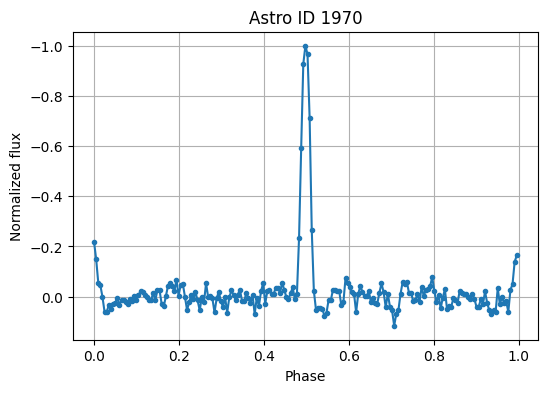

4055
Distance: 7.7326459884643555


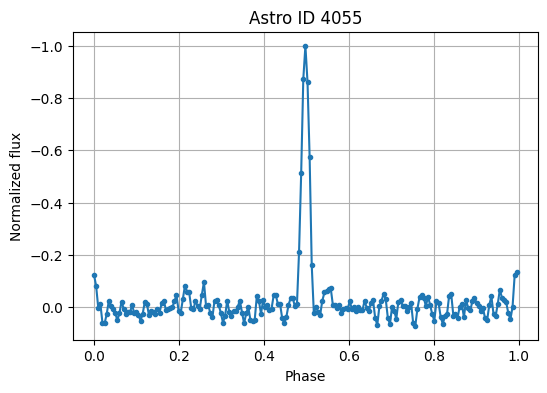

701
Distance: 7.965028762817383


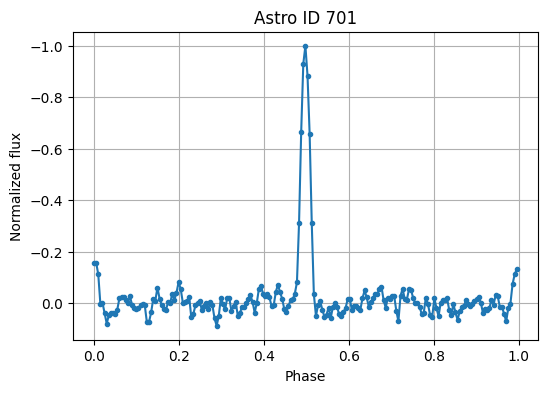

3900
Distance: 8.158596992492676


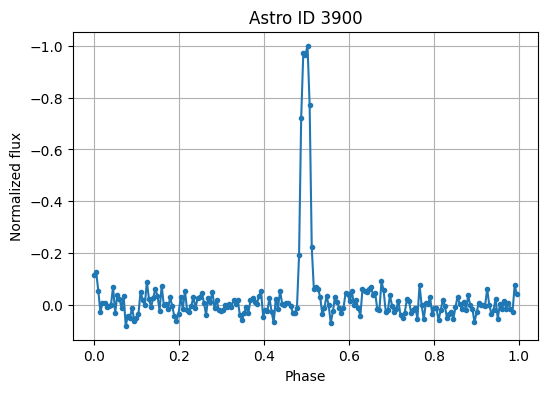

500
Distance: 8.563185691833496


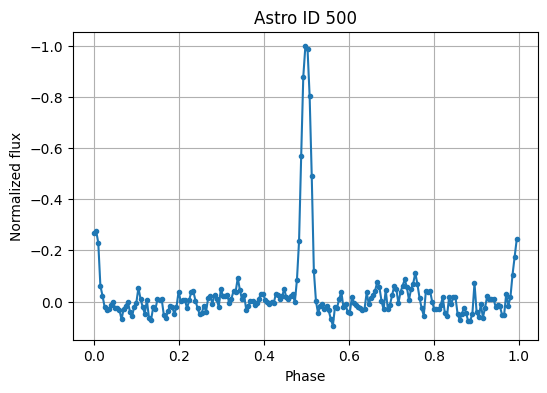

In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

def robust_z(x):
    m = np.median(x); s = 1.4826*np.median(np.abs(x - m))
    return (x - m) / (s + 1e-8)

# collect
ids, X = [], []
for astro_id, view in id_to_view.items():
    X.append(robust_z(view))
    ids.append(astro_id)

X = np.vstack(X).astype(np.float32)
print(X)

# embed + index
pca = PCA(n_components=32, random_state=0).fit(X)
Z = pca.transform(X)
#Z = X

nn = NearestNeighbors(n_neighbors=10, metric='euclidean').fit(Z)

def neighbors_by_id(astro_id, k=10):
    i = ids.index(astro_id)
    d, idx = nn.kneighbors(Z[i].reshape(1, -1), n_neighbors=k)
    return [(ids[j], float(dist)) for j, dist in zip(idx[0], d[0])]


id_to_inspect = ids[85]
nn = neighbors_by_id(id_to_inspect)
for i in range(0, 5):
    nn_id = nn[i][0]
    print(nn_id)
    print('Distance: ' + str(nn[i][1]))
    view_lc(id_to_view[nn_id], nn_id)


Index(['astro_id', 'Dec', 'Decision', 'Depth', 'Dur', 'Epoc', 'File', 'Final',
       'Per', 'RA', 'SMass', 'SRad', 'SRadEst', 'TIC ID', 'Tmag', 'as', 'ch',
       'disp_b', 'disp_e', 'disp_j', 'disp_n', 'disp_p', 'disp_t', 'disp_u',
       'dm', 'et', 'md', 'mk', 'total_votes', 'selected_total_votes',
       'first_letter'],
      dtype='object')


/pdo/users/dimond/conda/envs/dimond-conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/pdo/users/dimond/conda/envs/dimond-conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/pdo/users/dimond/conda/envs/dimond-conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_70010/1301585493.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = plt.cm.get_cmap('tab20', len(uniq_true))


<Figure size 700x600 with 0 Axes>

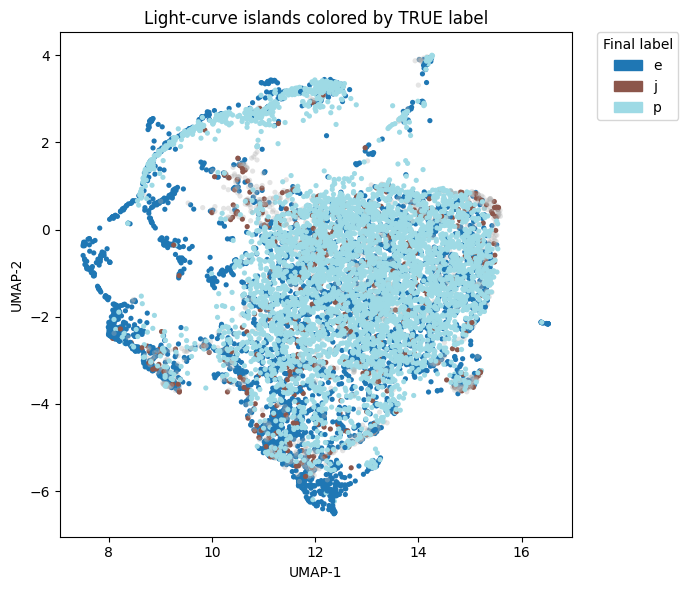

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import matplotlib.patches as mpatches

import umap
import hdbscan

#properties = '/pdo/astronet-data/data/labels/sector_85_to_87_analysis.csv'
all_properties = pd.read_csv(properties)
all_properties = all_properties.rename(columns={'Astro ID': 'astro_id'})
all_properties['Final'] = all_properties['Final'].str[0]

print(all_properties.columns)

# 0) start from your X (robust_z already applied)
# optional: remove extreme outliers
norms = np.linalg.norm(X, axis=1)
keep = norms < np.quantile(norms, 0.995)
Xc = X[keep]; ids_c = [ids[i] for i,k in enumerate(keep) if k]

# 1) Low-dim embedding for clustering (whitened PCA → 32D)
pca = PCA(n_components=64, whiten=True, random_state=0).fit(Xc)
Z = pca.transform(Xc)

# 2) Emphasize *shape* not magnitude: cosine works well
# (normalize rows to unit length)
Z_cos = normalize(Z, norm='l2', axis=1)

# 3) Cluster with HDBSCAN (metric='euclidean' on normalized vectors ~ cosine)
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=10, cluster_selection_epsilon=0.01)
labels = clusterer.fit_predict(Z_cos)

# 4) 2-D viz (UMAP on the same Z_cos)
u = umap.UMAP(n_neighbors=15, min_dist=0.05, metric='euclidean', random_state=0)
viz = u.fit_transform(Z_cos)

# 5) Plot
id_to_true = dict(zip(all_properties['astro_id'], all_properties['Final']))
true_labels = [id_to_true.get(aid, None) for aid in ids_c]  # align with viz order

plt.figure(figsize=(7,6))

uniq_true = np.unique([lb for lb in true_labels if lb is not None])
palette = plt.cm.get_cmap('tab20', len(uniq_true))

# map true label → color index
label_to_color = {lb: palette(i) for i, lb in enumerate(uniq_true)}

colors = [label_to_color.get(lb, (0.7,0.7,0.7,0.35)) for lb in true_labels]

plt.figure(figsize=(7,6))
plt.scatter(viz[:,0], viz[:,1], s=14, c=colors, linewidths=0)

plt.title("Light-curve islands colored by TRUE label")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# build legend patches
patches = [mpatches.Patch(color=color, label=str(lb)) 
           for lb, color in label_to_color.items()]

plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left',
           borderaxespad=0., title="Final label")

plt.tight_layout()
plt.show()

# plt.figure(figsize=(7,6))
# uniq = np.unique(labels)
# colors = []
# palette = plt.cm.get_cmap('tab20', max(1, len(uniq[(uniq!=-1)])))
# for lb in labels:
#     if lb == -1:
#         colors.append((0.7,0.7,0.7,0.35))
#     else:
#         colors.append(palette(lb % palette.N))
# plt.scatter(viz[:,0], viz[:,1], s=14, c=colors, linewidths=0)
# plt.title("Light-curve islands (PCA→HDBSCAN, UMAP viz)")
# plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.tight_layout(); plt.show()

# Utilities
from collections import defaultdict
cluster_to_idx = defaultdict(list)
for i, lb in enumerate(labels):
    cluster_to_idx[lb].append(i)

def cluster_sizes():
    return {lb: len(ix) for lb, ix in sorted(cluster_to_idx.items(),
                                             key=lambda kv: -len(kv[1]))}

def show_cluster(lb, n=9):
    import random
    idxs = cluster_to_idx.get(lb, [])
    for i in random.sample(idxs, min(n, len(idxs))):
        astro_id = ids_c[i]
        print(all_properties[all_properties['astro_id'] == astro_id])
        view_lc(id_to_view[astro_id], astro_id)

In [11]:
print(cluster_sizes())

{-1: 7820, 6: 974, 2: 206, 5: 152, 7: 76, 1: 44, 8: 35, 3: 13, 0: 12, 4: 10}


    astro_id       Dec Decision        Depth       Dur         Epoc  \
55        56  27.98063      NaN  13683.84053  0.219916  1875.244979   

                                                 File Final      Per  \
55  mk_hlsp_qlp_tess_ffi-s0021-0000000117378334_te...    pt  8.85056   

            RA  ...  disp_p  disp_t  disp_u   dm  et  md  mk  total_votes  \
55  131.975877  ...       1       1       0  NaN  pt  pt  pt            2   

    selected_total_votes  first_letter  
55                     1             p  

[1 rows x 31 columns]


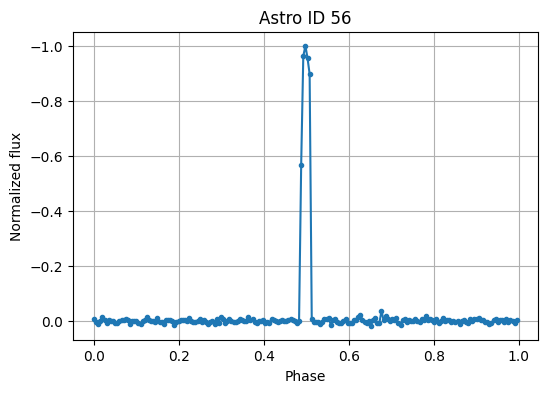

     astro_id        Dec Decision        Depth       Dur         Epoc  \
505       511  31.376546      NaN  189732.2198  0.142621  1931.954365   

                                                  File Final       Per  \
505  mk_hlsp_qlp_tess_ffi-s0023-0000000165976940_te...    et  5.940198   

             RA  ...  disp_p  disp_t  disp_u   dm  et  md  mk  total_votes  \
505  195.358081  ...       0       1       0  NaN  et  et  et            2   

     selected_total_votes  first_letter  
505                     1             e  

[1 rows x 31 columns]


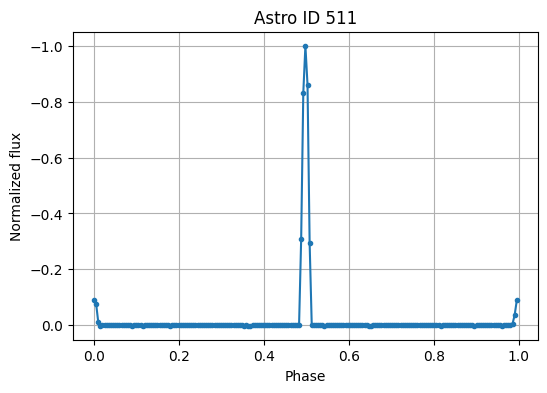

      astro_id        Dec Decision        Depth       Dur        Epoc  \
1172      1187  59.091572      NaN  251766.7895  0.386396  1793.64393   

                                                   File Final       Per  \
1172  mk_hlsp_qlp_tess_ffi-s0018-0000000347949236_te...    et  5.278934   

             RA  ...  disp_p  disp_t  disp_u   dm  et  md  mk  total_votes  \
1172  33.909234  ...       0       1       0  NaN  et  et  et            2   

      selected_total_votes  first_letter  
1172                     1             e  

[1 rows x 31 columns]


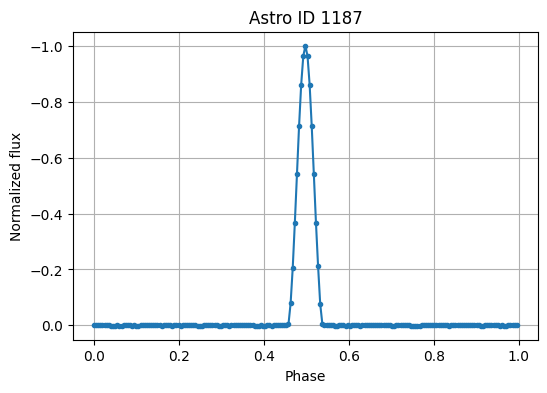

      astro_id        Dec Decision        Depth       Dur         Epoc  \
5538      6079  44.776963      NaN  7067.953778  0.294921  1958.081146   

                                                   File Final       Per  \
5538  astronet_hlsp_qlp_tess_ffi-s0064-0000000198588...    pu  4.810103   

              RA  ...  disp_p  disp_t  disp_u   dm   et   md   mk  \
5538  256.610671  ...       1       0       1  NaN  NaN  NaN  NaN   

      total_votes  selected_total_votes  first_letter  
5538            2                     1             p  

[1 rows x 31 columns]


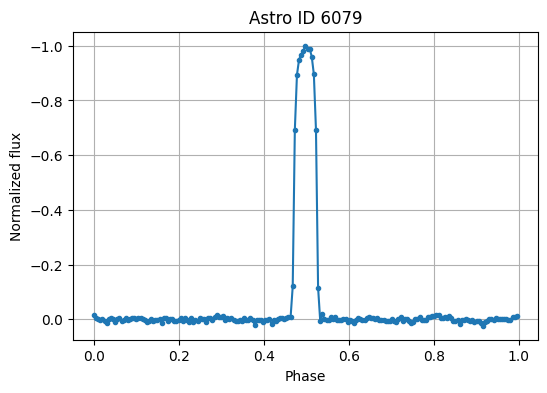

      astro_id        Dec Decision       Depth       Dur         Epoc  \
4538      4782  30.673575      NaN  19635.0001  0.112022  1794.854856   

                                                   File Final      Per  \
4538  astronet_hlsp_qlp_tess_ffi-s0064-0000000085593...    pu  3.72248   

             RA  ...  disp_p  disp_t  disp_u   dm   et   md   mk  total_votes  \
4538  47.368928  ...       1       0       1  NaN  NaN  NaN  NaN            2   

      selected_total_votes  first_letter  
4538                     1             p  

[1 rows x 31 columns]


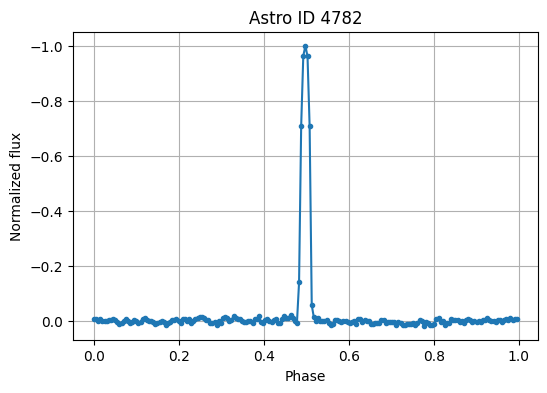

      astro_id        Dec Decision        Depth     Dur         Epoc  \
7352      8474 -82.218882      NaN  6137.812234  0.2118  1601.989703   

                                                   File Final       Per  \
7352  astronet_hlsp_qlp_tess_ffi-s0064-0000000394561...    pu  4.078243   

              RA  ...  disp_p  disp_t  disp_u   dm   et   md   mk  \
7352  155.607575  ...       1       0       1  NaN  NaN  NaN  NaN   

      total_votes  selected_total_votes  first_letter  
7352            2                     1             p  

[1 rows x 31 columns]


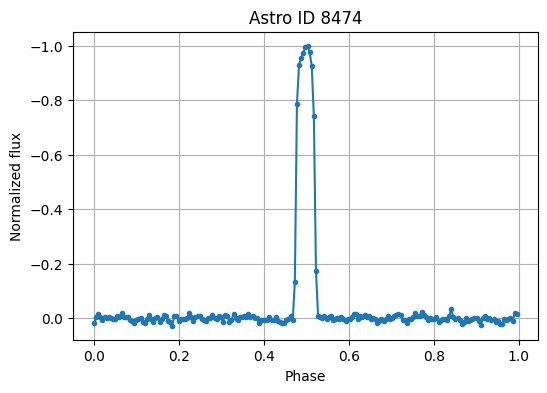

      astro_id        Dec Decision        Depth       Dur         Epoc  \
1234      1249 -80.220238      NaN  57607.15613  0.254033  1327.412575   

                                                   File Final       Per  \
1234  mk_hlsp_qlp_tess_ffi-s0028-0000000358501560_te...    et  3.711878   

             RA  ...  disp_p  disp_t  disp_u   dm  et  md  mk  total_votes  \
1234  60.954445  ...       0       1       0  NaN  et  et  et            2   

      selected_total_votes  first_letter  
1234                     1             e  

[1 rows x 31 columns]


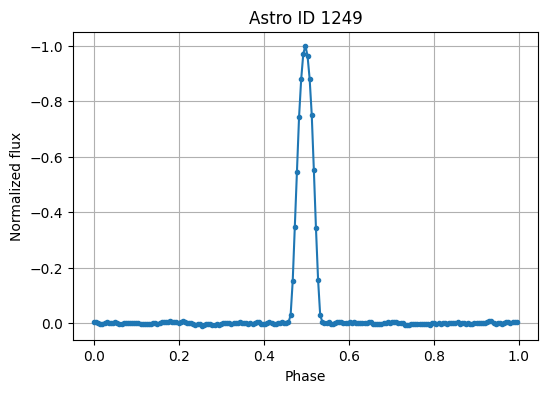

      astro_id        Dec Decision        Depth       Dur         Epoc  \
2227      2263  57.390459      NaN  25161.44896  0.245601  1713.723725   

                                                   File Final      Per  \
2227  mk_hlsp_qlp_tess_ffi-s0022-0000000207493152_te...    et  9.12724   

              RA  ...  disp_p  disp_t  disp_u  dm  et   md  mk  total_votes  \
2227  246.542125  ...       0       1       0  et  et  NaN  et            2   

      selected_total_votes  first_letter  
2227                     1             e  

[1 rows x 31 columns]


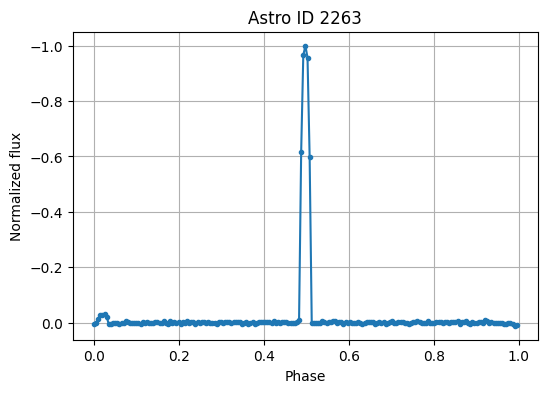

In [13]:
show_cluster(2, n=8)

In [15]:
print(all_properties['Final'])

0        et
1        eb
2        eb
3        et
4        eb
         ..
15466    jj
15467    jj
15468    jj
15469    jj
15470    jj
Name: Final, Length: 15471, dtype: object
